In [1]:

import warnings
warnings.filterwarnings('ignore')

import shutil

import numpy as np
import torch
import random
import ViMST as vim 
from pathlib import Path
import scanpy as sc
import pandas as pd
from sklearn import metrics
import os
from utils import refine
from s_dbw import S_Dbw


def train_one(args, adata, tissue_name=' '):
    # 初始化模型
    net = vim.ViMST(adata,
                     tissue_name=tissue_name,
                     num_clusters=args.n_clusters,
                     genes_model='pca',
                     top_genes=args.top_genes,
                     rad_cutoff=args.rad_cutoff,
                     k_cutoff=args.k_cutoff,
                     graph_model='Radius',
                     device=torch.device('cuda:0' if torch.cuda.is_available() else 'cpu'),
                     learning_rate=args.learning_rate,
                     weight_decay=args.weight_decay,
                     max_epoch=args.max_epoch,
                     gradient_clipping=args.gradient_clipping,
                     feat_mask_rate=args.feat_mask_rate,
                     img_mask_rate=args.img_mask_rate,
                     edge_drop_rate=args.edge_drop_rate,
                     hidden_dim=args.hidden_dim,
                     latent_dim=args.latent_dim,
                     bn=args.bn,
                     att_dropout_rate=args.att_dropout_rate,
                     fc_dropout_rate=args.fc_dropout_rate,
                     use_token=args.use_token,
                     rep_loss=args.rep_loss,
                     rel_loss=args.rel_loss,
                     alpha=args.alpha,
                     lam=args.lam,
                     random_seed=args.seed,
                     nps=args.nps)
    net.train()
    method = "kmeans"
    net.process(method=method)
    adata = net.get_adata()


    adata.obs["refined_pred"] = vim.utils.spatial_domains_refinement_ez_mode(sample_id=adata.obs.index.tolist(),
                                                                       pred=adata.obs["kmeans"].tolist(), x_array=adata.obs['array_row'],
                                                                       y_array=adata.obs['array_col'], shape="hexagon")
    adata.obs["refined_pred"] = adata.obs["kmeans"].astype('category') 
    
    # 输出预测评估指标
    print(f"adata.obsm['eval_pred'].shape:{adata.obsm['eval_pred'].shape}")

    return adata



adata.obsm['feat'].shape:(3124, 300)
gene_recon 维度: torch.Size([3124, 3000])
adata.obsm['fea1'].shape:(3124, 300)
------Calculating spatial graph...
The graph contains 18018 edges, 3124 cells.
5.7676 neighbors per cell on average.
(3124, 300)


Dataset_Name:mouse_kidney, Ep 499: train loss:0.1423: 100%|██████████| 500/500 [01:42<00:00,  4.86it/s]


Calculateing adj matrix using xy only...
adata.obsm['eval_pred'].shape:(3124, 8)


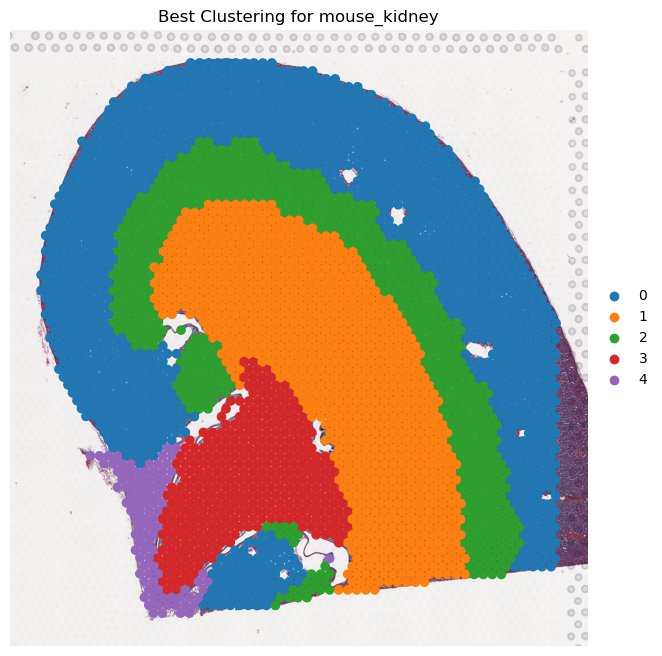

In [2]:

import matplotlib.pyplot as plt
from ViMST.utils import build_args

# 初始化其他参数
args = build_args()
args.hidden_dim, args.latent_dim = 512, 256
args.max_epoch = 500
args.top_genes = 3000
args.n_clusters = 5
args.lam = 1.3
args.feat_mask_rate = 0.3
args.img_mask_rate = 0.5
#最佳
args.rad_cutoff = 350 #定了 k=5!!!!!!!!
args.nps = 4 #定了14
args.edge_drop_rate = 0.5 #定了0.5
# 数据路径
data_root = Path("/home/dingcheng/data/") 

section_id = ["mouse_kidney"] 
for tissue_name in section_id:
    data_root = Path("/home/dingcheng/data/")
    input_dir = os.path.join(data_root, tissue_name)
    
    adata = sc.read_visium(path=input_dir, count_file='filtered_feature_bc_matrix.h5')
    adata = train_one(args, adata, tissue_name)
    output_path = f"/home/Data/Results_Kidney/ViMST_Results/{tissue_name}_processed.h5ad"
    adata.write(output_path)
    
    

    # 绘制最佳配置下的聚类图
    fig, ax = plt.subplots(figsize=(16, 8))
    sc.pl.spatial(adata, color=['kmeans'], show=False, spot_size=310, ax=ax)
    ax.set_title(f"Best Clustering for {tissue_name}")  
    ax.axis('off')
    plt.show()
 

In [3]:


# 然后将其转换为有序类别
adata.obs["refined_pred"] = adata.obs["refined_pred"].cat.as_ordered()


dav = metrics.davies_bouldin_score(adata.obsm['eval_pred'], adata.obs["refined_pred"])
cal = metrics.calinski_harabasz_score(adata.obsm['eval_pred'], adata.obs["refined_pred"])
sil = metrics.silhouette_score(adata.obsm['eval_pred'], adata.obs["refined_pred"])



sdbw = np.round(S_Dbw(adata.obsm['eval_pred'], adata.obs["refined_pred"]), 5)
# Ann_df = pd.read_csv('./metadata.tsv', sep='\t')
# ARI = np.round(metrics.adjusted_rand_score(y_pred, Ann_df['fine_annot_type']), 3)
# NMI = np.round(metrics.normalized_mutual_info_score(y_pred, Ann_df['fine_annot_type']), 3)
print("dav:", dav)
print("cal:", cal)
print("sil:", sil)
print("sdbw:", sdbw)

dav: 0.699526057432653
cal: 3307.893334925455
sil: 0.552016
sdbw: 0.50197


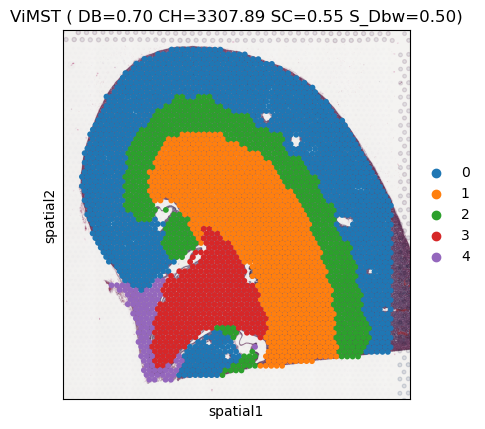

<Figure size 640x480 with 0 Axes>

In [5]:
# 绘制聚类图并保存为 PDF 文件
sc.pl.spatial(adata, color=['refined_pred'], title='ViMST ( DB=%.2f CH=%.2f SC=%.2f S_Dbw=%.2f)' % (dav, cal, sil, sdbw), spot_size=310)
save_path = f'/home/Data/Results_Kidney/ViMST_Results/cluster.pdf'
plt.savefig(save_path, dpi=600)

